# Figure 6: Variant contribution sensitivity analysis

This notebook regenerates a code-aligned Figure 6 from the local
**ExposoGraph** package.

**Package-alignment notes**

- Synthetic genotypes are sampled from `ExposoGraph.population_simulation._core`
  using the bundled ancestry-specific genotype tables and haplotype blocks.
- The simulation uses 10,000 synthetic individuals for each of five ancestry
  strata: EUR, EAS, AFR, AMR, and SAS.
- Flux profiles are computed with `ExposoGraph.flux_engine.compute_full_profile()`
  under the same Tier 1 / background, liver-context convention used for
  Figure 5.
- The composite score is the same relative index used in Figure 5: the
  geometric mean of class-wise median-normalized activation/detoxification
  net ratios.
- Variant contribution is estimated by **feature neutralization**: for each
  modeled variant, carriers are reset to the package reference state, the
  ExposoGraph flux profile is recomputed, and the reduction in variance of
  the log2 composite score is recorded. Bars are normalized across modeled
  features with positive variance reduction.

**Genes that drive flux-profile variation in this notebook**

After the round of population-module additions and modifier-table
corrections that shipped with this figure, twelve sampled genes change
`compute_full_profile()` outputs in liver tissue: ALDH2, CYP1A1, CYP1A2,
CYP1B1, CYP2E1, EPHX1, GSTM1, GSTP1, GSTT1, NAT1, NAT2, NQO1. CYP1A2
heterozygotes (`*1A/*1F`) and NAT1 star-allele diplotypes were silently
treated as wild-type prior to those fixes; they now register their proper
intermediate effects.

**Variants still excluded from the bar chart**

Several variants used in earlier draft figures (NQO1*2, UGT1A1*28, XRCC1
R399Q, OGG1 S326C, ABCG2 Q141K, ADH1B*2, MGMT promoter methylation) were
absent from the population sampling tables. NQO1 has now been added to the
tables and appears in the figure; the rest remain in the `legacy_variant`
audit CSV with the reason they are excluded. Several genes that
`compute_full_profile()` actively queries (CYP3A4, CYP2A6, CYP2A13, GSTA1,
COMT, SULT1E1, UGT2B7, AS3MT, ALDH1A1, XPC, ERCC2, POLH) are also still
held at NM by the population module and are listed in the audit CSV so the
figure's normalization scope is transparent.

In [1]:
from __future__ import annotations

import csv
import math
import random
import statistics
import sys
import warnings
from collections import OrderedDict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "ExposoGraph").is_dir() and (candidate / "pyproject.toml").exists():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the ExposoGraph repository root.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ExposoGraph.flux_engine import compute_full_profile
from ExposoGraph.population_simulation._core import (
    ALLELE_FREQUENCIES,
    HAPLOTYPE_BLOCKS,
    _genes_covered_by_blocks,
    _weighted_pick,
    sample_haplotype_block,
)

OUTPUT_DIR = REPO_ROOT / "Figures_Notebook" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

N_PER_ANCESTRY = 10_000
SEED = 20260430
TISSUE = "Liver"
EPS = 1e-9

ANCESTRIES = OrderedDict(
    [
        ("EUR", "European"),
        ("EAS", "East Asian"),
        ("AFR", "African"),
        ("AMR", "Admixed American"),
        ("SAS", "South Asian"),
    ]
)

DISPLAY_NAMES = {
    "EUR": "European",
    "EAS": "East Asian",
    "AFR": "African/African American",
    "AMR": "Latino/Admixed",
    "SAS": "South Asian",
}

SAMPLED_GENES = tuple(
    sorted(
        set(ALLELE_FREQUENCIES)
        | {gene for block in HAPLOTYPE_BLOCKS.values() for gene in block["genes"]}
    )
)

# Genes whose sampled diplotypes change compute_full_profile() outputs in
# liver tissue. Verified empirically by perturbing each gene off NM and
# checking that at least one carcinogen class shifts.
PROFILE_GENES = (
    "ALDH2",
    "CYP1A1",
    "CYP1A2",
    "CYP1B1",
    "CYP2E1",
    "EPHX1",
    "GSTM1",
    "GSTP1",
    "GSTT1",
    "NAT1",
    "NAT2",
    "NQO1",
)

CATEGORY_COLORS = {
    "Phase I activation": "#007c89",
    "Aldehyde / oxidative detox": "#d89c00",
    "Phase II conjugation": "#b65a32",
}

plt.rcParams.update(
    {
        "font.size": 8,
        "axes.titlesize": 9,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
    }
)

warnings.filterwarnings("ignore", message="Unrecognized diplotype")

print(f"Repository root: {REPO_ROOT}")
print(f"Sampled genes ({len(SAMPLED_GENES)}): {', '.join(SAMPLED_GENES)}")
print(f"Profile-active sampled genes ({len(PROFILE_GENES)}): {', '.join(PROFILE_GENES)}")

Repository root: /Users/julhashkazi/Documents/ExposoGraph_work
Sampled genes (19): ALDH2, CYP1A1, CYP1A2, CYP1B1, CYP2B6, CYP2C19, CYP2C8, CYP2C9, CYP2D6, CYP2E1, CYP3A5, EPHX1, GSTM1, GSTM3, GSTP1, GSTT1, NAT1, NAT2, NQO1
Profile-active sampled genes (12): ALDH2, CYP1A1, CYP1A2, CYP1B1, CYP2E1, EPHX1, GSTM1, GSTP1, GSTT1, NAT1, NAT2, NQO1


## Simulate genotype profiles

Sampling mirrors the Figure 5 notebook: haplotype blocks are drawn first,
then independent gene-level samples are added for genes not covered by
those blocks.

In [2]:
def sample_genotypes_for_ancestry(rng: random.Random, ancestry_label: str) -> dict[str, str]:
    genotypes: dict[str, str] = {}
    covered_genes = _genes_covered_by_blocks()

    for block_name in HAPLOTYPE_BLOCKS:
        genotypes.update(sample_haplotype_block(rng, block_name, ancestry_label))

    for gene, per_ancestry in ALLELE_FREQUENCIES.items():
        if gene in covered_genes:
            continue
        genotypes[gene] = _weighted_pick(rng, per_ancestry[ancestry_label])

    return genotypes


profile_cache: dict[tuple[tuple[str, str], ...], dict[str, float]] = {}


def profile_key(genotypes: dict[str, str]) -> tuple[tuple[str, str], ...]:
    return tuple((gene, str(genotypes.get(gene, ""))) for gene in PROFILE_GENES)


def profile_ratios(genotypes: dict[str, str]) -> dict[str, float]:
    key = profile_key(genotypes)
    if key not in profile_cache:
        profile_input = {gene: str(genotypes.get(gene, "")) for gene in PROFILE_GENES}
        profile = compute_full_profile(profile_input, tissue=TISSUE)
        profile_cache[key] = {
            class_name: float(result.net_ratio)
            for class_name, result in profile.per_class_results.items()
        }
    return profile_cache[key]


rng = random.Random(SEED)
rows: list[dict[str, object]] = []

for ancestry_code, ancestry_label in ANCESTRIES.items():
    for index in range(N_PER_ANCESTRY):
        genotypes = sample_genotypes_for_ancestry(rng, ancestry_label)
        ratios = profile_ratios(genotypes)
        rows.append(
            {
                "person_id": f"{ancestry_code}{index:05d}",
                "ancestry_code": ancestry_code,
                "ancestry_label": ancestry_label,
                "display_name": DISPLAY_NAMES[ancestry_code],
                "genotypes": genotypes,
                "ratios": ratios,
            }
        )

print(f"Simulated {len(rows):,} individuals.")
print(f"Unique cached profile states: {len(profile_cache):,}")
print(f"Modeled carcinogen classes: {len(rows[0]['ratios'])}")

Simulated 50,000 individuals.
Unique cached profile states: 14,079
Modeled carcinogen classes: 15


## Compute the relative composite score

Each carcinogen class is median-normalized across the pooled simulated
cohort. The composite score is the geometric mean of the normalized
class-specific net ratios. Variance is computed on the log2 score because
the score is multiplicative.

In [3]:
class_names = list(rows[0]["ratios"])

class_medians: dict[str, float] = {}
for class_name in class_names:
    values = [
        float(row["ratios"][class_name])
        for row in rows
        if float(row["ratios"][class_name]) > 0
    ]
    class_medians[class_name] = statistics.median(values) if values else 1.0


def composite_score_from_ratios(ratios: dict[str, float]) -> float:
    components = []
    for class_name in class_names:
        ratio = max(float(ratios[class_name]), EPS)
        median = max(float(class_medians[class_name]), EPS)
        components.append(math.log(ratio / median))
    return math.exp(sum(components) / len(components))


def variance(values: list[float]) -> float:
    if not values:
        return 0.0
    mean = sum(values) / len(values)
    return sum((value - mean) ** 2 for value in values) / len(values)


for row in rows:
    score = composite_score_from_ratios(row["ratios"])
    row["relative_composite_score"] = score
    row["relative_composite_log2"] = math.log2(score)

baseline_log2_scores = [float(row["relative_composite_log2"]) for row in rows]
baseline_variance = variance(baseline_log2_scores)

print(f"Baseline log2 composite variance: {baseline_variance:.6f}")
print(
    "Composite score range: "
    f"{min(row['relative_composite_score'] for row in rows):.3f} to "
    f"{max(row['relative_composite_score'] for row in rows):.3f}"
)

Baseline log2 composite variance: 0.019928
Composite score range: 0.833 to 1.707


## Feature-neutralization variance analysis

For each feature the notebook resets only individuals carrying that feature
to the package reference state, recomputes the ExposoGraph profile, and
measures how much log2 composite-score variance is removed.

**Methodological caveat.** Single-feature neutralization is a leave-one-out
approximation, not a Shapley-style decomposition. When haplotype-block
correlation between features is non-trivial, neutralizing one feature can
*increase* the residual variance of others; cases where
`raw_variance_reduction` is negative are clipped to zero before normalization,
which biases the displayed shares. CYP1A2*1F and NQO1*2 act on classes
(Aflatoxin and Benzene respectively) whose default kinetic parameters
produce large net-ratio swings under near-null phenotypes; their bars
therefore primarily reflect single-class dominance under the default
exposure concentration rather than balanced multi-class effects. Bars are
normalized against the modeled-feature subset only, not against the full
germline variance the flux engine could in principle resolve.

In [4]:
FEATURES = [
    {
        "key": "GSTM1_null",
        "label": "GSTM1 null",
        "category": "Phase II conjugation",
        "condition": lambda gt: gt.get("GSTM1") == "null",
        "neutralize": lambda gt: {**gt, "GSTM1": "present"},
        "reference_state": "GSTM1=present",
    },
    {
        "key": "GSTT1_null",
        "label": "GSTT1 null",
        "category": "Phase II conjugation",
        "condition": lambda gt: gt.get("GSTT1") == "null",
        "neutralize": lambda gt: {**gt, "GSTT1": "present"},
        "reference_state": "GSTT1=present",
    },
    {
        "key": "GSTP1_PM",
        "label": "GSTP1 Val/Val",
        "category": "Phase II conjugation",
        "condition": lambda gt: gt.get("GSTP1") == "PM",
        "neutralize": lambda gt: {**gt, "GSTP1": "NM"},
        "reference_state": "GSTP1=NM",
    },
    {
        "key": "GSTP1_IM",
        "label": "GSTP1 Ile/Val",
        "category": "Phase II conjugation",
        "condition": lambda gt: gt.get("GSTP1") == "IM",
        "neutralize": lambda gt: {**gt, "GSTP1": "NM"},
        "reference_state": "GSTP1=NM",
    },
    {
        "key": "NAT2_slow",
        "label": "NAT2 slow",
        "category": "Phase II conjugation",
        "condition": lambda gt: gt.get("NAT2") == "slow",
        "neutralize": lambda gt: {**gt, "NAT2": "rapid"},
        "reference_state": "NAT2=rapid",
    },
    {
        "key": "NAT2_intermediate",
        "label": "NAT2 intermediate",
        "category": "Phase II conjugation",
        "condition": lambda gt: gt.get("NAT2") == "intermediate",
        "neutralize": lambda gt: {**gt, "NAT2": "rapid"},
        "reference_state": "NAT2=rapid",
    },
    {
        "key": "NAT1_star14_carrier",
        "label": "NAT1*14 carrier",
        "category": "Phase II conjugation",
        "condition": lambda gt: "*14" in str(gt.get("NAT1", "")),
        "neutralize": lambda gt: {**gt, "NAT1": "*4/*4"},
        "reference_state": "NAT1=*4/*4",
    },
    {
        "key": "NAT1_star10_homozygote",
        "label": "NAT1*10/*10",
        "category": "Phase II conjugation",
        "condition": lambda gt: gt.get("NAT1") == "*10/*10",
        "neutralize": lambda gt: {**gt, "NAT1": "*4/*4"},
        "reference_state": "NAT1=*4/*4",
    },
    {
        "key": "ALDH2_star2",
        "label": "ALDH2*2 carrier",
        "category": "Aldehyde / oxidative detox",
        "condition": lambda gt: "*2" in str(gt.get("ALDH2", "")),
        "neutralize": lambda gt: {**gt, "ALDH2": "*1/*1"},
        "reference_state": "ALDH2=*1/*1",
    },
    {
        "key": "EPHX1_PM",
        "label": "EPHX1 slow (Y113H/Y113H)",
        "category": "Aldehyde / oxidative detox",
        "condition": lambda gt: gt.get("EPHX1") == "PM",
        "neutralize": lambda gt: {**gt, "EPHX1": "NM"},
        "reference_state": "EPHX1=NM",
    },
    {
        "key": "EPHX1_IM",
        "label": "EPHX1 intermediate",
        "category": "Aldehyde / oxidative detox",
        "condition": lambda gt: gt.get("EPHX1") == "IM",
        "neutralize": lambda gt: {**gt, "EPHX1": "NM"},
        "reference_state": "EPHX1=NM",
    },
    {
        "key": "NQO1_PM",
        "label": "NQO1*2/*2",
        "category": "Aldehyde / oxidative detox",
        "condition": lambda gt: gt.get("NQO1") == "PM",
        "neutralize": lambda gt: {**gt, "NQO1": "NM"},
        "reference_state": "NQO1=NM",
    },
    {
        "key": "NQO1_IM",
        "label": "NQO1*1/*2",
        "category": "Aldehyde / oxidative detox",
        "condition": lambda gt: gt.get("NQO1") == "IM",
        "neutralize": lambda gt: {**gt, "NQO1": "NM"},
        "reference_state": "NQO1=NM",
    },
    {
        "key": "CYP1A1_star2A",
        "label": "CYP1A1*2A carrier",
        "category": "Phase I activation",
        "condition": lambda gt: "*2A" in str(gt.get("CYP1A1", "")),
        "neutralize": lambda gt: {**gt, "CYP1A1": "WT"},
        "reference_state": "CYP1A1=WT",
    },
    {
        "key": "CYP1A2_1F_homozygote",
        "label": "CYP1A2*1F/*1F",
        "category": "Phase I activation",
        "condition": lambda gt: gt.get("CYP1A2") == "*1F/*1F",
        "neutralize": lambda gt: {**gt, "CYP1A2": "*1A/*1A"},
        "reference_state": "CYP1A2=*1A/*1A",
    },
    {
        "key": "CYP1A2_1F_heterozygote",
        "label": "CYP1A2*1A/*1F",
        "category": "Phase I activation",
        "condition": lambda gt: gt.get("CYP1A2") == "*1A/*1F",
        "neutralize": lambda gt: {**gt, "CYP1A2": "*1A/*1A"},
        "reference_state": "CYP1A2=*1A/*1A",
    },
    {
        "key": "CYP1B1_star3_homozygote",
        "label": "CYP1B1*3/*3 (Val/Val)",
        "category": "Phase I activation",
        "condition": lambda gt: gt.get("CYP1B1") == "UM",
        "neutralize": lambda gt: {**gt, "CYP1B1": "NM"},
        "reference_state": "CYP1B1=NM",
    },
    {
        "key": "CYP1B1_star3_heterozygote",
        "label": "CYP1B1*1/*3 (Leu/Val)",
        "category": "Phase I activation",
        "condition": lambda gt: gt.get("CYP1B1") == "RM",
        "neutralize": lambda gt: {**gt, "CYP1B1": "NM"},
        "reference_state": "CYP1B1=NM",
    },
    {
        "key": "CYP2E1_UM",
        "label": "CYP2E1 UM (*1C/*1C)",
        "category": "Phase I activation",
        "condition": lambda gt: gt.get("CYP2E1") == "UM_c1c1",
        "neutralize": lambda gt: {**gt, "CYP2E1": "NM"},
        "reference_state": "CYP2E1=NM",
    },
    {
        "key": "CYP2E1_IM",
        "label": "CYP2E1 IM",
        "category": "Phase I activation",
        "condition": lambda gt: gt.get("CYP2E1") == "IM",
        "neutralize": lambda gt: {**gt, "CYP2E1": "NM"},
        "reference_state": "CYP2E1=NM",
    },
]


contribution_rows: list[dict[str, object]] = []

for feature in FEATURES:
    modified_log2_scores: list[float] = []
    carrier_count = 0
    for row in rows:
        genotypes = row["genotypes"]
        if feature["condition"](genotypes):
            carrier_count += 1
            neutralized = feature["neutralize"](genotypes)
            ratios = profile_ratios(neutralized)
            score = composite_score_from_ratios(ratios)
            modified_log2_scores.append(math.log2(score))
        else:
            modified_log2_scores.append(float(row["relative_composite_log2"]))

    neutralized_variance = variance(modified_log2_scores)
    raw_reduction = baseline_variance - neutralized_variance
    positive_reduction = max(0.0, raw_reduction)
    contribution_rows.append(
        {
            "feature_key": feature["key"],
            "label": feature["label"],
            "category": feature["category"],
            "reference_state": feature["reference_state"],
            "carrier_count": carrier_count,
            "carrier_frequency_percent": round(100 * carrier_count / len(rows), 3),
            "baseline_log2_variance": round(baseline_variance, 8),
            "neutralized_log2_variance": round(neutralized_variance, 8),
            "raw_variance_reduction": round(raw_reduction, 8),
            "positive_variance_reduction": positive_reduction,
        }
    )

positive_total = sum(float(row["positive_variance_reduction"]) for row in contribution_rows)
for row in contribution_rows:
    row["normalized_contribution_percent"] = (
        round(100 * float(row["positive_variance_reduction"]) / positive_total, 3)
        if positive_total > 0
        else 0.0
    )

contribution_rows.sort(key=lambda row: float(row["normalized_contribution_percent"]), reverse=True)

for row in contribution_rows:
    print(
        f"{row['label']:<28} "
        f"freq={row['carrier_frequency_percent']:>6.2f}% "
        f"contribution={row['normalized_contribution_percent']:>6.2f}%"
    )

GSTM1 null                   freq= 40.74% contribution= 31.22%
NQO1*2/*2                    freq=  9.68% contribution= 30.78%
ALDH2*2 carrier              freq= 10.77% contribution=  9.73%
CYP1A1*2A carrier            freq= 21.38% contribution=  6.53%
GSTP1 Val/Val                freq= 10.77% contribution=  5.29%
CYP1A2*1F/*1F                freq= 10.83% contribution=  4.26%
CYP2E1 IM                    freq=  9.17% contribution=  2.74%
GSTT1 null                   freq= 27.03% contribution=  2.10%
CYP2E1 UM (*1C/*1C)          freq= 14.95% contribution=  1.87%
GSTP1 Ile/Val                freq= 42.22% contribution=  1.75%
NAT2 slow                    freq= 29.33% contribution=  1.39%
CYP1A2*1A/*1F                freq= 21.58% contribution=  1.13%
EPHX1 slow (Y113H/Y113H)     freq=  6.85% contribution=  0.61%
NAT2 intermediate            freq= 38.16% contribution=  0.40%
EPHX1 intermediate           freq= 30.45% contribution=  0.19%
NAT1*14 carrier              freq= 10.60% contribution=

## Export source tables

Three CSVs are exported alongside the figure:

- `figure6_variant_variance_contributions.csv`: per-feature carrier counts,
  raw and clipped variance reductions, and the normalized contribution shares
  used in the bar chart.
- `figure6_variant_sensitivity_population_scores.csv`: the simulated cohort
  with each individual's sampled genotypes and composite score.
- `figure6_legacy_variant_audit.csv`: features either previously sampled but
  silently treated as wild-type (now active), no longer planned, or used by
  the flux engine but not yet sampled by the population module.

In [5]:
contribution_csv = OUTPUT_DIR / "figure6_variant_variance_contributions.csv"
with contribution_csv.open("w", newline="", encoding="utf-8") as handle:
    fieldnames = [
        "feature_key",
        "label",
        "category",
        "reference_state",
        "carrier_count",
        "carrier_frequency_percent",
        "baseline_log2_variance",
        "neutralized_log2_variance",
        "raw_variance_reduction",
        "positive_variance_reduction",
        "normalized_contribution_percent",
    ]
    writer = csv.DictWriter(handle, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(contribution_rows)

population_csv = OUTPUT_DIR / "figure6_variant_sensitivity_population_scores.csv"
with population_csv.open("w", newline="", encoding="utf-8") as handle:
    fieldnames = [
        "person_id",
        "ancestry_code",
        "ancestry_label",
        "display_name",
        *SAMPLED_GENES,
        "relative_composite_score",
        "relative_composite_log2",
    ]
    writer = csv.DictWriter(handle, fieldnames=fieldnames)
    writer.writeheader()
    for row in rows:
        genotypes = row["genotypes"]
        writer.writerow(
            {
                "person_id": row["person_id"],
                "ancestry_code": row["ancestry_code"],
                "ancestry_label": row["ancestry_label"],
                "display_name": row["display_name"],
                **{gene: genotypes.get(gene, "") for gene in SAMPLED_GENES},
                "relative_composite_score": round(float(row["relative_composite_score"]), 6),
                "relative_composite_log2": round(float(row["relative_composite_log2"]), 6),
            }
        )

audit_rows = [
    # Previously silent / now active after package fixes
    {
        "feature": "NAT1 *4/*4, *4/*10, *10/*10, *4/*14, *14/*14",
        "status": "now_active_after_modifier_table_fix",
        "note": (
            "NAT1 sampled diplotypes were silently treated as NM until "
            "genotype_modifier was extended with NAT1 phenotype mappings "
            "(*4=1.0, *10=1.1, *14=0.5 with linear hetero blends)."
        ),
    },
    {
        "feature": "CYP1A2 *1A/*1F",
        "status": "now_active_after_modifier_table_fix",
        "note": (
            "Heterozygous *1F was silently treated as NM until genotype_modifier "
            "was extended with a *1A/*1F entry mapped to 1.25 (intermediate "
            "inducibility)."
        ),
    },
    # Newly sampled in this revision
    {
        "feature": "CYP1B1 (Leu432Val *3)",
        "status": "newly_sampled_in_this_revision",
        "note": (
            "Used by PAH, HCA, EstrogenMetabolites, and Dioxin. Added to "
            "ALLELE_FREQUENCIES with NM/RM/UM phenotype labels mapped to the "
            "standard 1.0/1.5/2.0 scale."
        ),
    },
    {
        "feature": "EPHX1 (Y113H, H139R)",
        "status": "newly_sampled_in_this_revision",
        "note": (
            "Used by PAH and VinylChloride. Added with PM/IM/NM/RM phenotypes "
            "matching the slow / intermediate / wild-type / fast hydrolase scale."
        ),
    },
    {
        "feature": "NQO1 (Pro187Ser *2)",
        "status": "newly_sampled_in_this_revision",
        "note": (
            "Used by Benzene. Added with NM/IM/PM phenotype labels representing "
            "*1/*1, *1/*2, and *2/*2 (~5% activity) genotypes."
        ),
    },
    {
        "feature": "GSTP1 (Ile105Val)",
        "status": "newly_sampled_in_this_revision",
        "note": (
            "Used by PAH, AromaticAmines, EstrogenMetabolites, NDEA. Added "
            "with NM/IM/PM labels for Ile/Ile, Ile/Val, Val/Val."
        ),
    },
    # Still-missing flux-active genes (held at NM by the population module)
    {
        "feature": "CYP3A4",
        "status": "flux_active_but_not_sampled",
        "note": "Used by Aflatoxin activation; not sampled by the population module.",
    },
    {
        "feature": "CYP2A6",
        "status": "flux_active_but_not_sampled",
        "note": "Used by Nitrosamine and NDEA; not sampled.",
    },
    {
        "feature": "CYP2A13",
        "status": "flux_active_but_not_sampled",
        "note": "Used by Nitrosamine and NDEA (extrahepatic); not sampled.",
    },
    {
        "feature": "GSTA1",
        "status": "flux_active_but_not_sampled",
        "note": "Used by Aflatoxin detox; not sampled.",
    },
    {
        "feature": "COMT, SULT1E1, UGT2B7",
        "status": "flux_active_but_not_sampled",
        "note": "Used by EstrogenMetabolites; not sampled.",
    },
    {
        "feature": "AS3MT",
        "status": "flux_active_but_not_sampled",
        "note": "Used by HeavyMetal arsenic methylation; not sampled.",
    },
    {
        "feature": "ALDH1A1",
        "status": "flux_active_but_not_sampled",
        "note": "Used by Aldehyde detox proxy term; not sampled.",
    },
    {
        "feature": "ADH1B",
        "status": "flux_active_but_not_sampled",
        "note": "Used by Aldehyde upstream alcohol oxidation; not sampled.",
    },
    {
        "feature": "XPC, ERCC2, OGG1, MGMT, POLH, XRCC1",
        "status": "flux_active_but_not_sampled",
        "note": (
            "Used by repair-pathway proxy terms across UV_Radiation, "
            "AromaticAmines, NDEA, EstrogenMetabolites; not sampled."
        ),
    },
    # Sampled but not active in compute_full_profile
    {
        "feature": "CYP3A5",
        "status": "sampled_but_not_active",
        "note": (
            "Sampled, but compute_full_profile() uses CYP3A4 for aflatoxin "
            "activation. CYP3A5 currently has no flux-engine consumer."
        ),
    },
    {
        "feature": "CYP2D6",
        "status": "sampled_but_not_active",
        "note": "Sampled with a modifier defined, but no carcinogen-class flux uses CYP2D6.",
    },
    {
        "feature": "CYP2B6, CYP2C8, CYP2C9, CYP2C19, GSTM3",
        "status": "sampled_but_not_active",
        "note": (
            "Sampled by ALLELE_FREQUENCIES or HAPLOTYPE_BLOCKS but not queried "
            "by any flux function in compute_full_profile()."
        ),
    },
    # Variants from earlier draft figures still excluded
    {
        "feature": "UGT1A1*28",
        "status": "not_sampled_and_not_active",
        "note": "Present in reference annotations; not sampled and not used by compute_full_profile().",
    },
    {
        "feature": "ABCG2 Q141K",
        "status": "not_sampled_and_not_active",
        "note": "Present in reference annotations; not sampled and not used by compute_full_profile().",
    },
]

audit_csv = OUTPUT_DIR / "figure6_legacy_variant_audit.csv"
with audit_csv.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(audit_rows[0].keys()))
    writer.writeheader()
    writer.writerows(audit_rows)

print(contribution_csv)
print(population_csv)
print(audit_csv)

/Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output/figure6_variant_variance_contributions.csv
/Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output/figure6_variant_sensitivity_population_scores.csv
/Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output/figure6_legacy_variant_audit.csv


## Render Figure 6

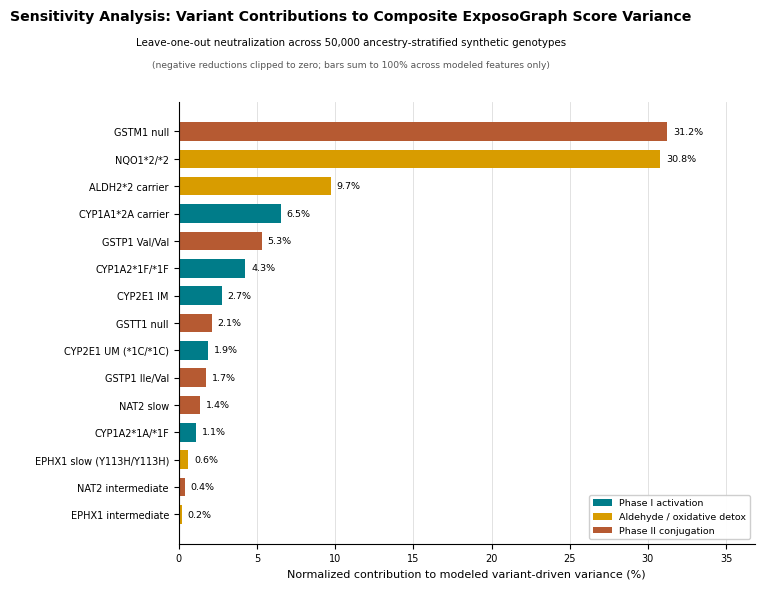

/Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output/figure6_variant_contributions_sensitivity_analysis.png
/Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output/figure6_variant_contributions_sensitivity_analysis.pdf
/Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output/figure6_variant_contributions_sensitivity_analysis.svg


In [6]:
plot_rows = [
    row
    for row in contribution_rows
    if float(row["normalized_contribution_percent"]) > 0
]
plot_rows = sorted(plot_rows, key=lambda row: float(row["normalized_contribution_percent"]))

fig, ax = plt.subplots(figsize=(8.6, 6.4), constrained_layout=False)
fig.subplots_adjust(left=0.30, right=0.97, top=0.82, bottom=0.13)

y = np.arange(len(plot_rows))
values = [float(row["normalized_contribution_percent"]) for row in plot_rows]
colors = [CATEGORY_COLORS[str(row["category"])] for row in plot_rows]
labels = [str(row["label"]) for row in plot_rows]

ax.barh(y, values, color=colors, height=0.68)

for ypos, value in zip(y, values):
    ax.text(value + max(values) * 0.012, ypos, f"{value:.1f}%",
            va="center", ha="left", fontsize=6.8)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel("Normalized contribution to modeled variant-driven variance (%)")
ax.set_xlim(0, max(values) * 1.18 if values else 1)
ax.grid(axis="x", color="#dddddd", linewidth=0.6)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

legend_handles = [
    Patch(facecolor=color, edgecolor="none", label=category)
    for category, color in CATEGORY_COLORS.items()
    if category in {str(row["category"]) for row in plot_rows}
]
ax.legend(
    handles=legend_handles,
    loc="lower right",
    frameon=True,
    framealpha=0.95,
    fontsize=6.8,
)

fig.suptitle(
    "Sensitivity Analysis: Variant Contributions to Composite ExposoGraph Score Variance",
    fontsize=10.2,
    weight="bold",
    y=0.965,
)
fig.text(
    0.5,
    0.905,
    "Leave-one-out neutralization across 50,000 ancestry-stratified synthetic genotypes",
    ha="center",
    va="bottom",
    fontsize=7.4,
)
fig.text(
    0.5,
    0.872,
    "(negative reductions clipped to zero; bars sum to 100% across modeled features only)",
    ha="center",
    va="bottom",
    fontsize=6.6,
    color="#555",
)

png_path = OUTPUT_DIR / "figure6_variant_contributions_sensitivity_analysis.png"
pdf_path = OUTPUT_DIR / "figure6_variant_contributions_sensitivity_analysis.pdf"
svg_path = OUTPUT_DIR / "figure6_variant_contributions_sensitivity_analysis.svg"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(svg_path, bbox_inches="tight")
plt.show()

print(png_path)
print(pdf_path)
print(svg_path)